<a href="https://colab.research.google.com/github/jiki007/OS_project/blob/main/CronJobScheduler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib

import subprocess
import datetime
import time
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
# Each job simulates a real Ubuntu cron task
jobs = [
    {
        "name": "Log Rotation",
        "cmd": "echo '[LOG ROTATION] Old logs archived at $(date)'",
        "interval": 5,  # every 5 seconds (simulating minutes)
    },
    {
        "name": "Disk Cleanup",
        "cmd": "df -h | tail -1",
        "interval": 8,
    },
    {
        "name": "Memory Check",
        "cmd": "free -h | grep Mem",
        "interval": 6,
    },
    {
        "name": "System Uptime Check",
        "cmd": "uptime -p",
        "interval": 10,
    },
    {
        "name": "Backup Simulation",
        "cmd": "echo '[BACKUP] Files backed up successfully at $(date)'",
        "interval": 12,
    },
]

In [ ]:
# Store execution logs
execution_log = []

def run_job(job):
    start_time = datetime.datetime.now()
    try:
        result = subprocess.run(
            job["cmd"], shell=True,
            capture_output=True, text=True, timeout=5
        )
        status = "SUCCESS" if result.returncode == 0 else "FAILED"
        output = result.stdout.strip() if result.stdout else result.stderr.strip()
    except subprocess.TimeoutExpired:
        status = "TIMEOUT"
        output = "Job timed out"
    except Exception as e:
        status = "FAILED"
        output = str(e)

    end_time = datetime.datetime.now()
    duration = (end_time - start_time).total_seconds()

    log_entry = {
        "job": job["name"],
        "start": start_time,
        "end": end_time,
        "duration": round(duration, 2),
        "status": status,
        "output": output
    }
    execution_log.append(log_entry)

    print(f"[{start_time.strftime('%H:%M:%S')}] ⚙️ {job['name']}")
    print(f"  Status : {status}")
    print(f"  Output : {output}")
    print(f"  Duration: {duration:.2f}s\n")

def run_scheduler(total_runtime=30):
    print("🕐 Cron Job Scheduler Started")
    print(f"   Running for {total_runtime} seconds...\n")
    print("-" * 50)

    start = time.time()
    last_run = {job["name"]: 0 for job in jobs}

    while time.time() - start < total_runtime:
        now = time.time() - start
        for job in jobs:
            if now - last_run[job["name"]] >= job["interval"]:
                run_job(job)
                last_run[job["name"]] = now
        time.sleep(1)

    print("-" * 50)
    print(f"✅ Scheduler finished. Total jobs executed: {len(execution_log)}")

In [ ]:
run_scheduler(total_runtime=30)

🕐 Cron Job Scheduler Started
   Running for 30 seconds...

--------------------------------------------------
[00:38:00] ⚙️ Log Rotation
  Status : SUCCESS
  Output : [LOG ROTATION] Old logs archived at $(date)
  Duration: 0.01s

[00:38:01] ⚙️ Memory Check
  Status : SUCCESS
  Output : Mem:            12Gi       804Mi       8.7Gi       2.0Mi       3.2Gi        11Gi
  Duration: 0.03s

[00:38:03] ⚙️ Disk Cleanup
  Status : SUCCESS
  Output : tmpfs           6.4G     0  6.4G   0% /sys/firmware
  Duration: 0.00s

[00:38:05] ⚙️ Log Rotation
  Status : SUCCESS
  Output : [LOG ROTATION] Old logs archived at $(date)
  Duration: 0.00s

[00:38:05] ⚙️ System Uptime Check
  Status : SUCCESS
  Output : up 6 minutes
  Duration: 0.01s

[00:38:07] ⚙️ Memory Check
  Status : SUCCESS
  Output : Mem:            12Gi       839Mi       8.6Gi       2.0Mi       3.2Gi        11Gi
  Duration: 0.00s

[00:38:07] ⚙️ Backup Simulation
  Status : SUCCESS
  Output : [BACKUP] Files backed up successfully at $(date)
 

In [ ]:
def visualize_scheduler():
    if not execution_log:
        print("No execution data yet.")
        return

    # ── 1. Gantt Chart ──────────────────────────────────────
    job_names = list({e["job"] for e in execution_log})
    colors = plt.cm.tab10.colors
    color_map = {name: colors[i % 10] for i, name in enumerate(job_names)}

    fig, ax = plt.subplots(figsize=(14, 6))
    base_time = execution_log[0]["start"]

    for entry in execution_log:
        start_sec = (entry["start"] - base_time).total_seconds()
        duration = max(entry["duration"], 0.3)  # min width for visibility
        y = job_names.index(entry["job"])
        color = color_map[entry["job"]] if entry["status"] == "SUCCESS" else "red"
        ax.barh(y, duration, left=start_sec, height=0.4, color=color, edgecolor="black")

    ax.set_yticks(range(len(job_names)))
    ax.set_yticklabels(job_names)
    ax.set_xlabel("Time (seconds)")
    ax.set_title("Cron Job Scheduler - Gantt Chart", fontsize=14)

    success_patch = mpatches.Patch(color='steelblue', label='SUCCESS')
    fail_patch = mpatches.Patch(color='red', label='FAILED')
    ax.legend(handles=[success_patch, fail_patch])
    plt.tight_layout()
    plt.show()

    # ── 2. Success vs Failure Bar Chart ─────────────────────
    status_counts = {"SUCCESS": 0, "FAILED": 0, "TIMEOUT": 0}
    for entry in execution_log:
        status_counts[entry["status"]] += 1

    plt.figure(figsize=(7, 4))
    plt.bar(status_counts.keys(), status_counts.values(),
            color=["green", "red", "orange"], edgecolor="black")
    plt.title("Job Execution Results", fontsize=14)
    plt.xlabel("Status")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # ── 3. Execution Frequency per Job ──────────────────────
    from collections import Counter
    job_counts = Counter(e["job"] for e in execution_log)

    plt.figure(figsize=(10, 4))
    plt.bar(job_counts.keys(), job_counts.values(), color="steelblue", edgecolor="black")
    plt.title("Job Execution Frequency", fontsize=14)
    plt.xlabel("Job Name")
    plt.ylabel("Times Executed")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # ── 4. Execution Duration per Job ───────────────────────
    job_durations = {name: [] for name in job_names}
    for entry in execution_log:
        job_durations[entry["job"]].append(entry["duration"])
    avg_durations = {k: sum(v)/len(v) for k, v in job_durations.items()}

    plt.figure(figsize=(10, 4))
    plt.bar(avg_durations.keys(), avg_durations.values(), color="coral", edgecolor="black")
    plt.title("Average Execution Duration per Job", fontsize=14)
    plt.xlabel("Job Name")
    plt.ylabel("Avg Duration (seconds)")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

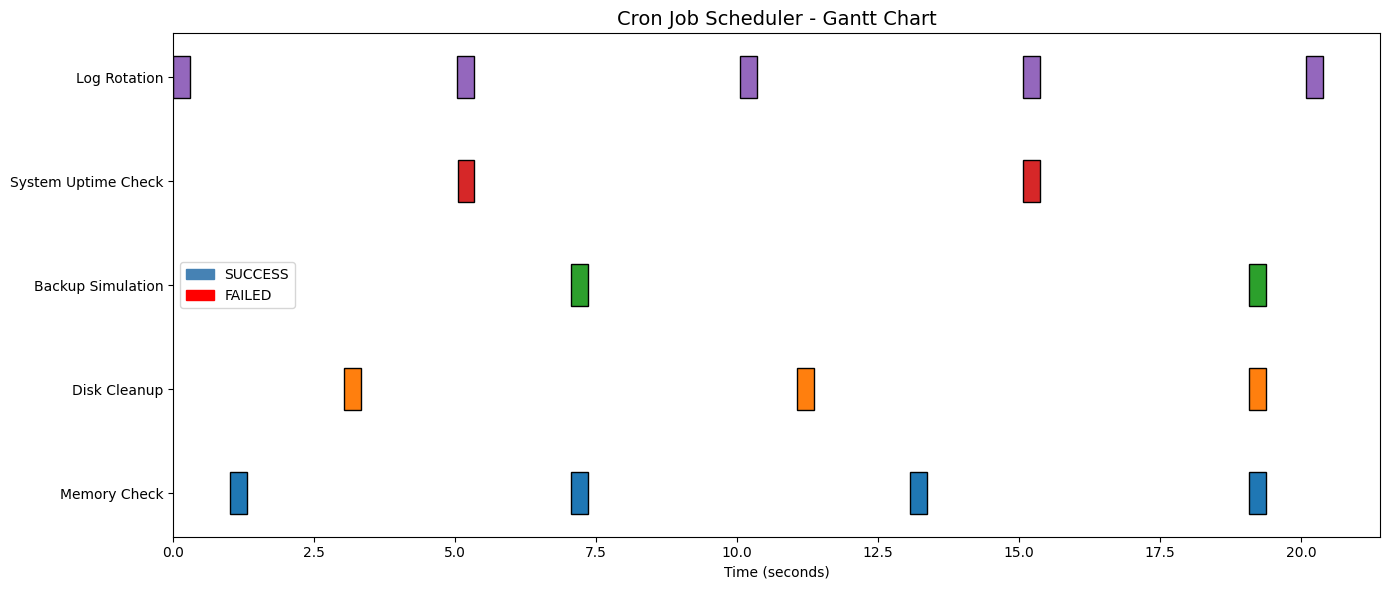

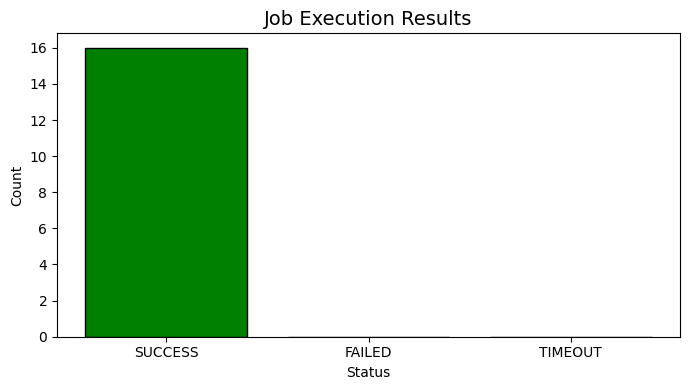

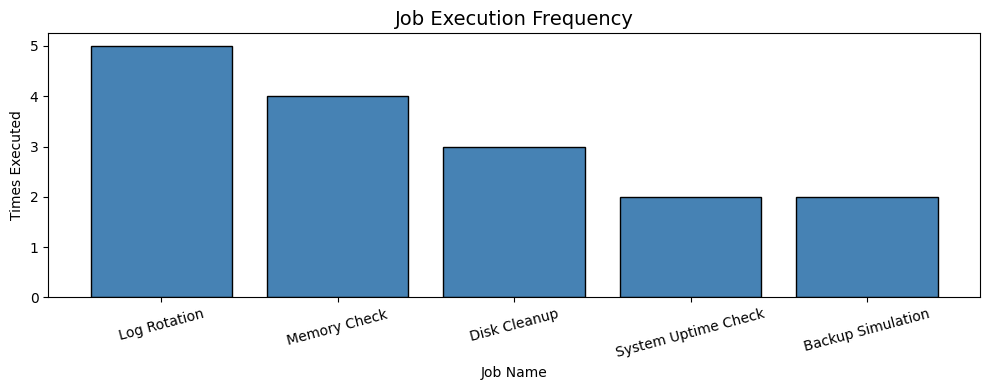

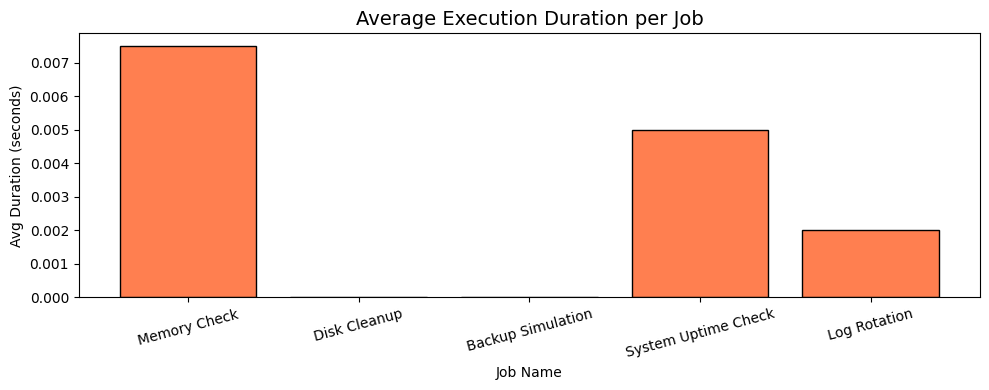

In [ ]:
visualize_scheduler()

In [ ]:
print(f"{'Job':<25} {'Start':<12} {'End':<12} {'Duration':<10} {'Status':<10} Output")
print("-" * 90)
for entry in execution_log:
    print(f"{entry['job']:<25} "
          f"{entry['start'].strftime('%H:%M:%S'):<12} "
          f"{entry['end'].strftime('%H:%M:%S'):<12} "
          f"{entry['duration']:<10} "
          f"{entry['status']:<10} "
          f"{entry['output'][:40]}")

Job                       Start        End          Duration   Status     Output
------------------------------------------------------------------------------------------
Log Rotation              00:38:00     00:38:00     0.01       SUCCESS    [LOG ROTATION] Old logs archived at $(da
Memory Check              00:38:01     00:38:01     0.03       SUCCESS    Mem:            12Gi       804Mi       8
Disk Cleanup              00:38:03     00:38:03     0.0        SUCCESS    tmpfs           6.4G     0  6.4G   0% /s
Log Rotation              00:38:05     00:38:05     0.0        SUCCESS    [LOG ROTATION] Old logs archived at $(da
System Uptime Check       00:38:05     00:38:05     0.01       SUCCESS    up 6 minutes
Memory Check              00:38:07     00:38:07     0.0        SUCCESS    Mem:            12Gi       839Mi       8
Backup Simulation         00:38:07     00:38:07     0.0        SUCCESS    [BACKUP] Files backed up successfully at
Log Rotation              00:38:10     00:38:10    